<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/comparativaestado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [64]:
diabetes= load_diabetes(as_frame= True)
x= diabetes.data
y= diabetes.target

In [65]:
#Estandarizaxion utilizando split entre los train-test
x_train, x_test, y_train, y_test= train_test_split(x, y , test_size= 0.2, random_state= 42)


In [66]:
sc= StandardScaler()
x_train_esc= sc.fit_transform(x_train)
x_test_esc= sc.transform(x_test)


In [67]:
modelo_arbol= DecisionTreeRegressor(max_depth= 5, random_state= 42)
modelo_arbol.fit(x_train_esc, y_train)
y_pred= modelo_arbol.predict(x_test_esc)

In [68]:
print("--- MÉTRICAS DEL ÁRBOL (max_depth=5) ---")
print(f'R²:   {r2_score(y_test, y_pred):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred):.2f} puntos')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} puntos\n')

--- MÉTRICAS DEL ÁRBOL (max_depth=5) ---
R²:   0.3345
MAE:  45.94 puntos
RMSE: 59.38 puntos



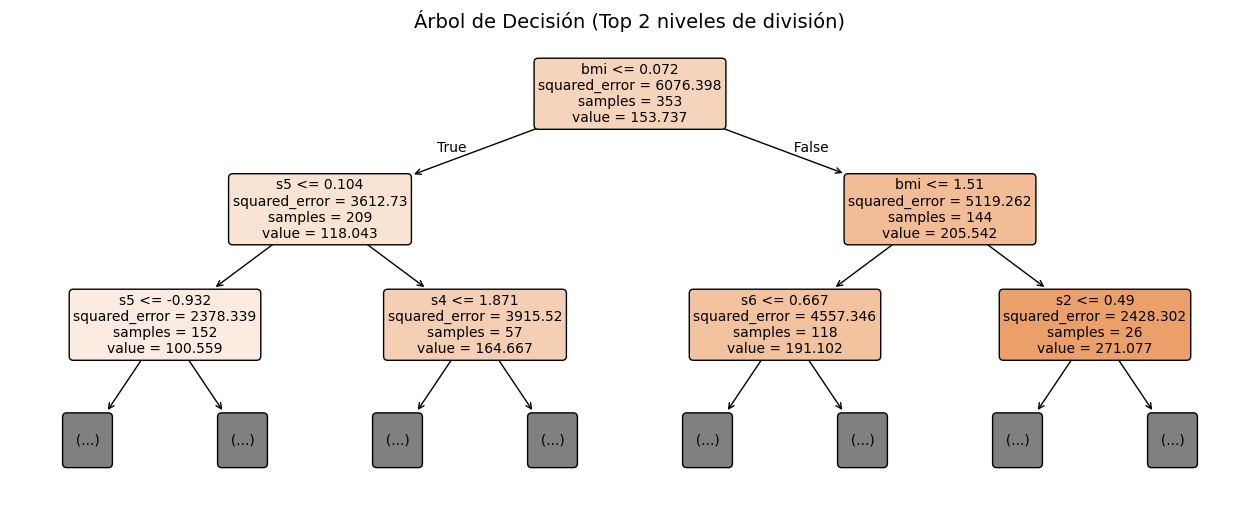

In [69]:
#Estimacion del arbol.
fig, ax = plt.subplots(figsize=(16, 6))

# Agregamos max_depth=2 para visualizar solo los cortes más importantes
plot_tree(modelo_arbol,
          max_depth=2,               # <--- ESTA ES LA MAGIA
          feature_names=x.columns,
          filled=True,
          rounded=True,
          fontsize=10,               # Subimos un poco la fuente para que se lea mejor
          ax=ax)

plt.title('Árbol de Decisión (Top 2 niveles de división)', fontsize=14)
plt.show()

In [70]:
depths= [1,2,4,5,7,10,15,20,None]
scores_train, scores_test= [], []

for d in depths:
  m= DecisionTreeRegressor(max_depth=d, random_state=42).fit(x_train_esc, y_train)
  scores_train.append(m.score(x_train_esc, y_train))
  scores_test.append(m.score(x_test_esc, y_test))

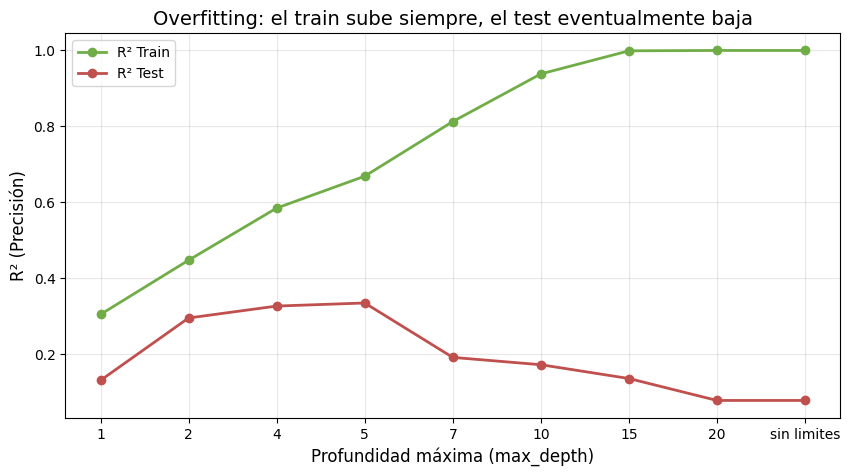

 Mira cómo el R² de train llega a casi 1.0 con árboles muy profundos.
   Pero el R² de test EMPIEZA A BAJAR — eso es overfitting.


In [71]:
fit, ax= plt.subplots(figsize=(10,5))
x_labels= [str(d) if d is not None else 'sin limites' for d in depths]

ax.plot(x_labels, scores_train, marker='o', linewidth=2, color='#70AD47', label='R² Train')
ax.plot(x_labels, scores_test, marker='o', linewidth=2, color='#C0504D', label='R² Test')

ax.set_xlabel('Profundidad máxima (max_depth)', fontsize=12)
ax.set_ylabel('R² (Precisión)', fontsize=12)
ax.set_title('Overfitting: el train sube siempre, el test eventualmente baja', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(' Mira cómo el R² de train llega a casi 1.0 con árboles muy profundos.')
print('   Pero el R² de test EMPIEZA A BAJAR — eso es overfitting.')

Ejercicio 3 — BENCHMARK: 3 modelos vs California Housing 🏠
Vamos a hacer nuestro primer benchmark serio: comparar Regresión Lineal, KNN y Árbol sobre un dataset nuevo y desafiante.

Dataset: fetch_california_housing de sklearn — 20,640 distritos de California con 8 features (NO es el csv que ya usaron — viene directo de sklearn).

Tarea:

Cargar el dataset:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target  # y = valor mediano de casa (en cientos de miles USD)
Train/test 80/20, random_state=42.
Estandarizar (lo necesitan Lineal y KNN; al Árbol no le afecta).
Entrenar 3 modelos:
LinearRegression()
KNeighborsRegressor(n_neighbors=10)
DecisionTreeRegressor(max_depth=8, random_state=42)
Construir un DataFrame de comparación con columnas: Modelo, R², MAE, RMSE.
Hacer un barplot comparando los R² de los 3 modelos.
Conclusión escrita: ¿qué modelo ganó? ¿Tiene sentido? (los precios de casas tienen relaciones no-lineales por geografía e ingreso).

In [72]:
data = fetch_california_housing(as_frame=True)
x= data.data
y= data.target

In [73]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 42)

In [74]:
# Estandirisacion
sc= StandardScaler()
x_train_esc= sc.fit_transform(x_train)
x_test_esc= sc.transform(x_test)


In [75]:
modelo_lr= LinearRegression()
modelo_knn= KNeighborsRegressor(n_neighbors= 10)
modelo_tree= DecisionTreeRegressor(max_depth= 8, random_state= 42)

--- TABLA COMPARATIVA DE MODELOS ---
             Modelo       R²      MAE     RMSE
   Regresión Lineal 0.575788 0.533200 0.745581
         KNN (k=10) 0.678314 0.440338 0.649261
Árbol (max_depth=8) 0.677928 0.448169 0.649650




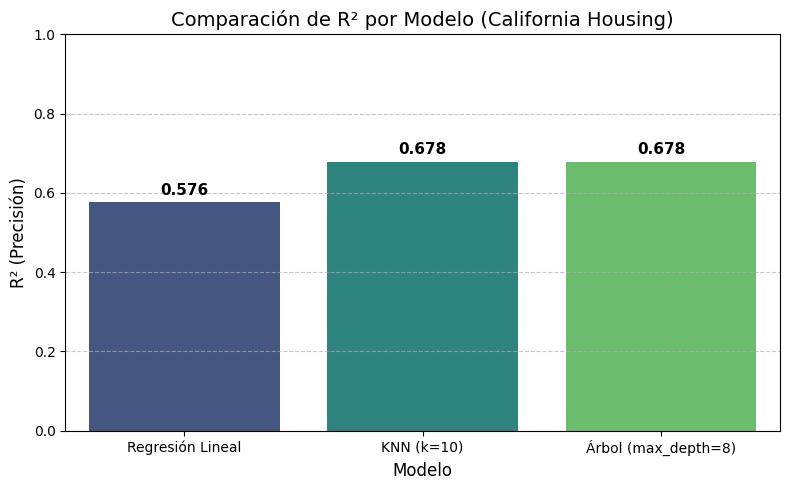

------------------------------------------------------------
--- CONCLUSIÓN DEL BENCHMARK ---
------------------------------------------------------------
🏆 El modelo GANADOR fue: KNN (k=10) (R² = 0.678)

¿Tiene sentido este resultado?
Absolutamente. La Regresión Lineal asume que las variables afectan el precio
en forma de línea recta constante. Sin embargo, los precios de las casas tienen
relaciones fuertemente NO-lineales. Por ejemplo, las coordenadas geográficas
(Latitud/Longitud) no aumentan el precio linealmente; los precios suben por
clústeres (zonas costeras, centros urbanos).

Los Árboles de Decisión y KNN ganan aquí porque son algoritmos no-lineales:
el Árbol puede segmentar el mapa en regiones y aplicar reglas específicas,
adaptándose perfectamente a la realidad del sector inmobiliario.


In [77]:
# =========================================================
# 1. Cargar el dataset
# =========================================================
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target  # Valor mediano en cientos de miles de USD

# =========================================================
# 2. Train/test split (80/20)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================
# 3. Estandarizar
# =========================================================
# Estandarizamos para Regresión Lineal y KNN. (Al árbol no le afecta, pero usamos los mismos datos por consistencia)
sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)

# =========================================================
# 4. Entrenar los 3 modelos
# =========================================================
# Instanciar
modelo_lr = LinearRegression()
modelo_knn = KNeighborsRegressor(n_neighbors=10)
modelo_tree = DecisionTreeRegressor(max_depth=8, random_state=42)

# Entrenar
modelo_lr.fit(X_train_esc, y_train)
modelo_knn.fit(X_train_esc, y_train)
modelo_tree.fit(X_train_esc, y_train)

# Predecir
pred_lr = modelo_lr.predict(X_test_esc)
pred_knn = modelo_knn.predict(X_test_esc)
pred_tree = modelo_tree.predict(X_test_esc)

# =========================================================
# 5. Construir DataFrame de comparación
# =========================================================
def calcular_metricas(y_real, y_pred, nombre_modelo):
    return {
        'Modelo': nombre_modelo,
        'R²': r2_score(y_real, y_pred),
        'MAE': mean_absolute_error(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred))
    }

resultados = [
    calcular_metricas(y_test, pred_lr, 'Regresión Lineal'),
    calcular_metricas(y_test, pred_knn, 'KNN (k=10)'),
    calcular_metricas(y_test, pred_tree, 'Árbol (max_depth=8)')
]

df_resultados = pd.DataFrame(resultados)
print("--- TABLA COMPARATIVA DE MODELOS ---")
print(df_resultados.to_string(index=False)) # to_string(index=False) imprime una tabla limpia sin números de fila
print("\n")

# =========================================================
# 6. Gráfico de barras comparativo (R²)
# =========================================================
plt.figure(figsize=(8, 5))
sns.barplot(data=df_resultados, x='Modelo', y='R²', hue='Modelo', palette='viridis', legend=False)

plt.title('Comparación de R² por Modelo (California Housing)', fontsize=14)
plt.ylabel('R² (Precisión)', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.ylim(0, 1) # Fijamos el eje Y de 0 a 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar el valor exacto sobre cada barra
for index, row in df_resultados.iterrows():
    plt.text(index, row['R²'] + 0.02, f"{row['R²']:.3f}", color='black', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================================
# 7. Selección del Ganador y Conclusión Escrita
# =========================================================
# Buscamos automáticamente el modelo con el valor máximo de R²
ganador = df_resultados.loc[df_resultados['R²'].idxmax()]

print("-" * 60)
print("--- CONCLUSIÓN DEL BENCHMARK ---")
print("-" * 60)
print(f"🏆 El modelo GANADOR fue: {ganador['Modelo']} (R² = {ganador['R²']:.3f})\n")

print("¿Tiene sentido este resultado?")
print("Absolutamente. La Regresión Lineal asume que las variables afectan el precio")
print("en forma de línea recta constante. Sin embargo, los precios de las casas tienen")
print("relaciones fuertemente NO-lineales. Por ejemplo, las coordenadas geográficas")
print("(Latitud/Longitud) no aumentan el precio linealmente; los precios suben por")
print("clústeres (zonas costeras, centros urbanos).")
print("\nLos Árboles de Decisión y KNN ganan aquí porque son algoritmos no-lineales:")
print("el Árbol puede segmentar el mapa en regiones y aplicar reglas específicas,")
print("adaptándose perfectamente a la realidad del sector inmobiliario.")

                      R²     MAE    RMSE
Modelo                                  
Regresión Lineal  0.5758  0.5332  0.7456
KNN (k=10)        0.6783  0.4403  0.6493
Árbol (depth=8)   0.6779  0.4482  0.6497


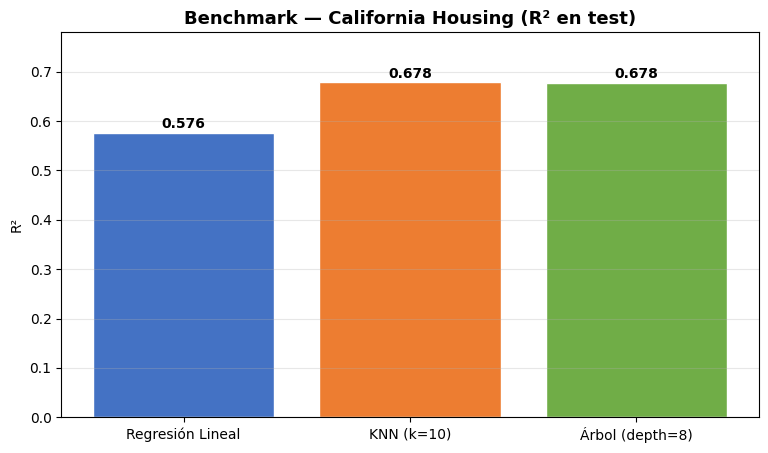

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Datos
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

# 2. Split + estandarización
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)

# 3. Entrenar y evaluar
modelos = {
    'Regresión Lineal':    (LinearRegression(),                               X_train_esc, X_test_esc),
    'KNN (k=10)':          (KNeighborsRegressor(n_neighbors=10),              X_train_esc, X_test_esc),
    'Árbol (depth=8)':     (DecisionTreeRegressor(max_depth=8, random_state=42), X_train, X_test),
}

resultados = []
for nombre, (modelo, Xtr, Xte) in modelos.items():
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    resultados.append({
        'Modelo': nombre,
        'R²':   r2_score(y_test, pred),
        'MAE':  mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(4)
print(df_resultados)

# 4. Barplot de R²
fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#4472C4', '#ED7D31', '#70AD47']
ax.bar(df_resultados.index, df_resultados['R²'], color=colores, edgecolor='white')
for i, v in enumerate(df_resultados['R²']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_title('Benchmark — California Housing (R² en test)', fontsize=13, fontweight='bold')
ax.set_ylabel('R²')
ax.set_ylim(0, max(df_resultados['R²']) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.show()